In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")

In [4]:
df = pd.read_excel('/Users/tajveer/Desktop/IPL_team_followers.xlsx')
df

,Rankings,Teams,Total Followers,Brand Value (USD),Net Worth (₹ Crore),FY25 Revenue (Rs Cr),Total Matches Played,Matches won,win_percentage
0,1,Chennai Super Kings,44.8M,$235 million,"₹2,033 Cr",674,255,142,0.556863
1,2,Mumbai Indians,41.4M,$242 million,"₹2,094 Cr",665,279,152,0.544803
2,3,Royal Challengers Bengaluru,38.4M,$269 million,"₹2,327 Cr",504,272,133,0.488971
3,4,Kolkata Knight Riders,30.8M,$222 million,"₹1,918 Cr",756,267,135,0.505618
4,5,Punjab Kings,17M,$141 million,"₹1,219 Cr",471,265,121,0.456604
5,6,Delhi Capitals,16.5M,$152 million,"₹1,314 Cr",603,268,120,0.447761
6,7,Sunrisers Hyderabad,15.5M,$154 million,"₹1,331 Cr",642,198,94,0.474747
7,8,Rajasthan Royals,14.1M,$146 million,"₹1,262 Cr",635,238,115,0.483193
8,9,Gujarat Titans,7.6M,$142 million,"₹1,227 Cr",559,62,37,0.596774
9,10,Lucknow Super Giants,5.8M,$122 million,"₹1,054 Cr",557,59,30,0.508475


In [5]:
df['Total Followers'] = df['Total Followers'].str.replace('M', '').astype(float)
df['Brand Value (USD)'] = df['Brand Value (USD)']\
    .str.replace('$', '')\
    .str.replace(' million', '')\
    .astype(float)
df['Net Worth (₹ Crore)'] = df['Net Worth (₹ Crore)']\
    .str.replace('₹', '')\
    .str.replace(',', '')\
    .str.replace(' Cr', '')\
    .astype(float)

In [6]:
df.columns = ['rank', 'team', 'followers_m', 'brand_value_usd_m', 'net_worth_cr','FY25 Revenue (Rs Cr)','total_matches_played', 'total_wins', 'win_percentage']
df

,rank,team,followers_m,brand_value_usd_m,net_worth_cr,FY25 Revenue (Rs Cr),total_matches_played,total_wins,win_percentage
0,1,Chennai Super Kings,44.8,235.0,2033.0,674,255,142,0.556863
1,2,Mumbai Indians,41.4,242.0,2094.0,665,279,152,0.544803
2,3,Royal Challengers Bengaluru,38.4,269.0,2327.0,504,272,133,0.488971
3,4,Kolkata Knight Riders,30.8,222.0,1918.0,756,267,135,0.505618
4,5,Punjab Kings,17.0,141.0,1219.0,471,265,121,0.456604
5,6,Delhi Capitals,16.5,152.0,1314.0,603,268,120,0.447761
6,7,Sunrisers Hyderabad,15.5,154.0,1331.0,642,198,94,0.474747
7,8,Rajasthan Royals,14.1,146.0,1262.0,635,238,115,0.483193
8,9,Gujarat Titans,7.6,142.0,1227.0,559,62,37,0.596774
9,10,Lucknow Super Giants,5.8,122.0,1054.0,557,59,30,0.508475


In [7]:
df['win_percentage']= df['total_wins'] / df['total_matches_played'] * 100
df['win_percentage'] = df['win_percentage'].map('{:.1f}%'.format)
df['win_percentage'] = df['win_percentage'].str.replace('%', '').astype(float)


df

,rank,team,followers_m,brand_value_usd_m,net_worth_cr,FY25 Revenue (Rs Cr),total_matches_played,total_wins,win_percentage
0,1,Chennai Super Kings,44.8,235.0,2033.0,674,255,142,55.7
1,2,Mumbai Indians,41.4,242.0,2094.0,665,279,152,54.5
2,3,Royal Challengers Bengaluru,38.4,269.0,2327.0,504,272,133,48.9
3,4,Kolkata Knight Riders,30.8,222.0,1918.0,756,267,135,50.6
4,5,Punjab Kings,17.0,141.0,1219.0,471,265,121,45.7
5,6,Delhi Capitals,16.5,152.0,1314.0,603,268,120,44.8
6,7,Sunrisers Hyderabad,15.5,154.0,1331.0,642,198,94,47.5
7,8,Rajasthan Royals,14.1,146.0,1262.0,635,238,115,48.3
8,9,Gujarat Titans,7.6,142.0,1227.0,559,62,37,59.7
9,10,Lucknow Super Giants,5.8,122.0,1054.0,557,59,30,50.8


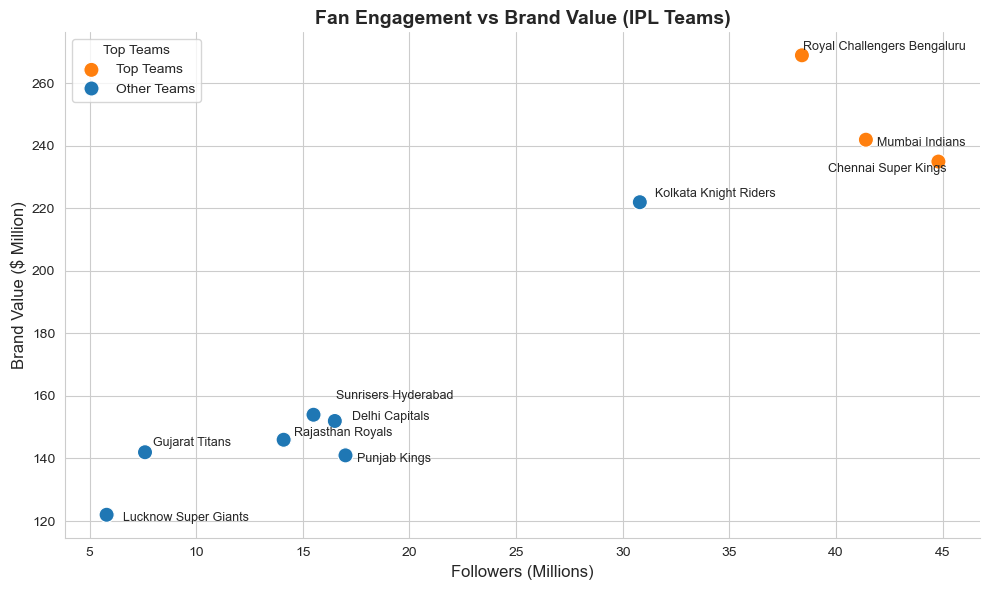

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# Create a column to highlight top teams
top_teams = ['Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bengaluru']
df['is_top_team'] = df['team'].isin(top_teams)

# Plot
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

sns.scatterplot(
    data=df,
    x='followers_m',
    y='brand_value_usd_m',
    hue='is_top_team',
    s=120
)
texts = []

for i in range(len(df)):
    texts.append(
        plt.text(df['followers_m'][i],
                 df['brand_value_usd_m'][i],
                 df['team'][i],
                 fontsize=9)
    )

adjust_text(texts)



# Titles and labels
plt.title("Fan Engagement vs Brand Value (IPL Teams)", fontsize=14, fontweight='bold')
plt.xlabel("Followers (Millions)", fontsize=12)
plt.ylabel("Brand Value ($ Million)", fontsize=12)

# Legend
plt.legend(title= 'Top Teams', labels=['Top Teams', 'Other Teams'], loc='upper left')

# Clean look
sns.despine()
plt.tight_layout()

plt.show()

In [9]:
df[['followers_m', 'brand_value_usd_m']].corr()
#Highy correlated! This means that teams with more followers tend to have higher brand values.

,followers_m,brand_value_usd_m
followers_m,1.000000,0.949775
brand_value_usd_m,0.949775,1.000000


In [29]:
df_sorted = df.sort_values('brand_value_usd_m', ascending=False)

/var/folders/23/m7plmfj94kb8p9ghd1v3b9lh0000gn/T/ipykernel_57124/597139284.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted, x='brand_value_usd_m', y='team', palette='rocket')


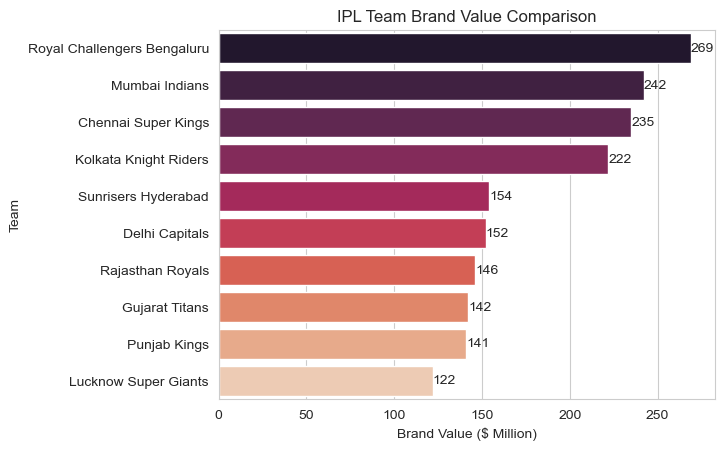

In [30]:
sns.barplot(data=df_sorted, x='brand_value_usd_m', y='team', palette='rocket')
plt.title("IPL Team Brand Value Comparison")
plt.xlabel("Brand Value ($ Million)")
plt.ylabel("Team")
for index, value in enumerate(df_sorted['brand_value_usd_m']):
    plt.text(value, index, f'{value:.0f}', va='center')



plt.show()


In [12]:
df['business_score'] = (
    0.5 * df['brand_value_usd_m'] +
    0.3 * df['followers_m'] +
    0.2 * df['net_worth_cr'] / 10
)
df_sorted = df.sort_values('business_score', ascending=False)
# A combined business score highlights overall franchise strength beyond single metrics.

/var/folders/23/m7plmfj94kb8p9ghd1v3b9lh0000gn/T/ipykernel_57124/2976908124.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


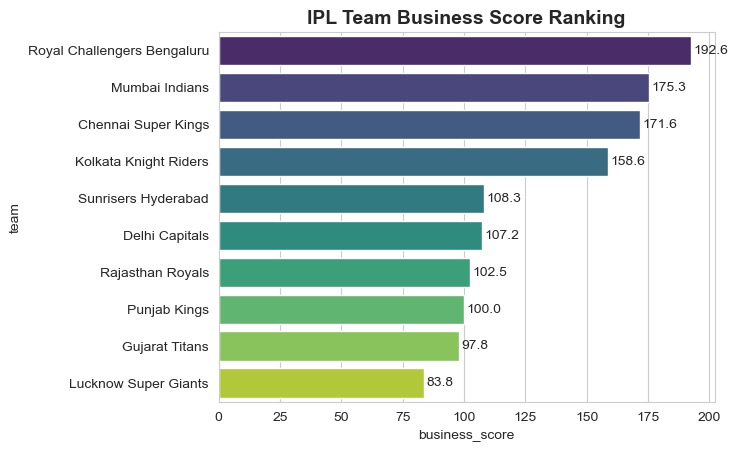

In [13]:
ax = sns.barplot(
    data=df_sorted,
    x='business_score',
    y='team',
    palette='viridis'
)

for i, v in enumerate(df_sorted['business_score']):
    ax.text(v + 1, i, f"{v:.1f}", va='center')

plt.title("IPL Team Business Score Ranking", fontsize=14, fontweight='bold')
plt.show()


In [14]:
df

,rank,team,followers_m,brand_value_usd_m,net_worth_cr,FY25 Revenue (Rs Cr),total_matches_played,total_wins,win_percentage,is_top_team,business_score
0,1,Chennai Super Kings,44.8,235.0,2033.0,674,255,142,55.7,True,171.60
1,2,Mumbai Indians,41.4,242.0,2094.0,665,279,152,54.5,True,175.30
2,3,Royal Challengers Bengaluru,38.4,269.0,2327.0,504,272,133,48.9,True,192.56
3,4,Kolkata Knight Riders,30.8,222.0,1918.0,756,267,135,50.6,False,158.60
4,5,Punjab Kings,17.0,141.0,1219.0,471,265,121,45.7,False,99.98
5,6,Delhi Capitals,16.5,152.0,1314.0,603,268,120,44.8,False,107.23
6,7,Sunrisers Hyderabad,15.5,154.0,1331.0,642,198,94,47.5,False,108.27
7,8,Rajasthan Royals,14.1,146.0,1262.0,635,238,115,48.3,False,102.47
8,9,Gujarat Titans,7.6,142.0,1227.0,559,62,37,59.7,False,97.82
9,10,Lucknow Super Giants,5.8,122.0,1054.0,557,59,30,50.8,False,83.82


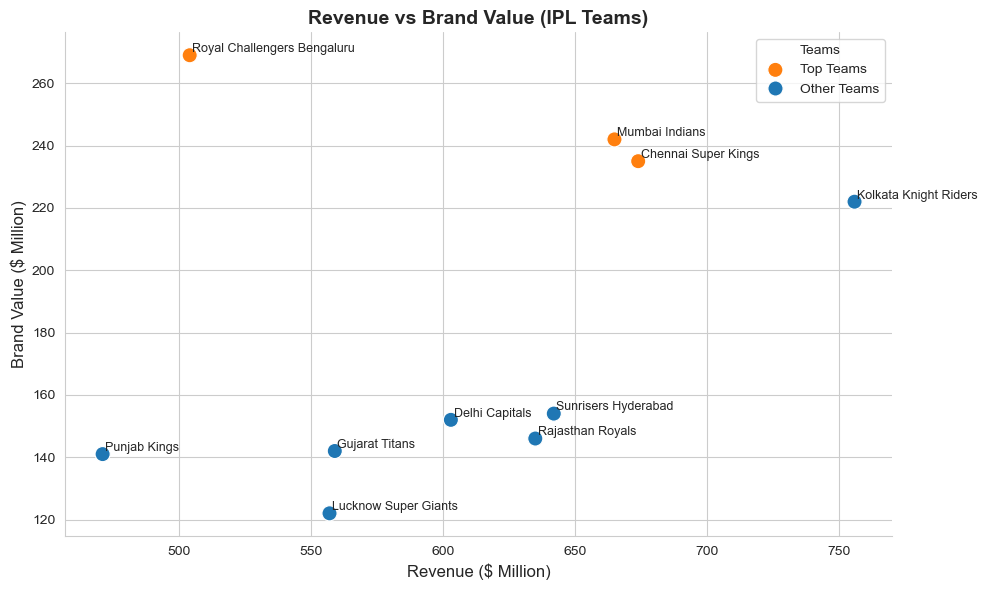

In [15]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

# Create a column to highlight top teams
top_teams = ['Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bengaluru']
df['is_top_team'] = df['team'].isin(top_teams)

sns.scatterplot(
    data=df,
    x='FY25 Revenue (Rs Cr)',
    y='brand_value_usd_m',
    hue= df['is_top_team'],
    s=120
)

# Add team labels
for i in range(len(df)):
    plt.text(
        df['FY25 Revenue (Rs Cr)'][i] + 1,
        df['brand_value_usd_m'][i] + 1,
        df['team'][i],
        fontsize=9
    )

# Titles and labels
plt.title("Revenue vs Brand Value (IPL Teams)", fontsize=14, fontweight='bold')
plt.xlabel("Revenue ($ Million)", fontsize=12)
plt.ylabel("Brand Value ($ Million)", fontsize=12)
plt.legend(title= 'Teams', labels=['Top Teams', 'Other Teams'], loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

In [16]:
df['revenue_per_fan'] = df['FY25 Revenue (Rs Cr)'] / df['followers_m']

df.sort_values('revenue_per_fan', ascending=False)[['team', 'revenue_per_fan']]

,team,revenue_per_fan
9,Lucknow Super Giants,96.034483
8,Gujarat Titans,73.552632
7,Rajasthan Royals,45.035461
6,Sunrisers Hyderabad,41.419355
5,Delhi Capitals,36.545455
4,Punjab Kings,27.705882
3,Kolkata Knight Riders,24.545455
1,Mumbai Indians,16.062802
0,Chennai Super Kings,15.044643
2,Royal Challengers Bengaluru,13.125000


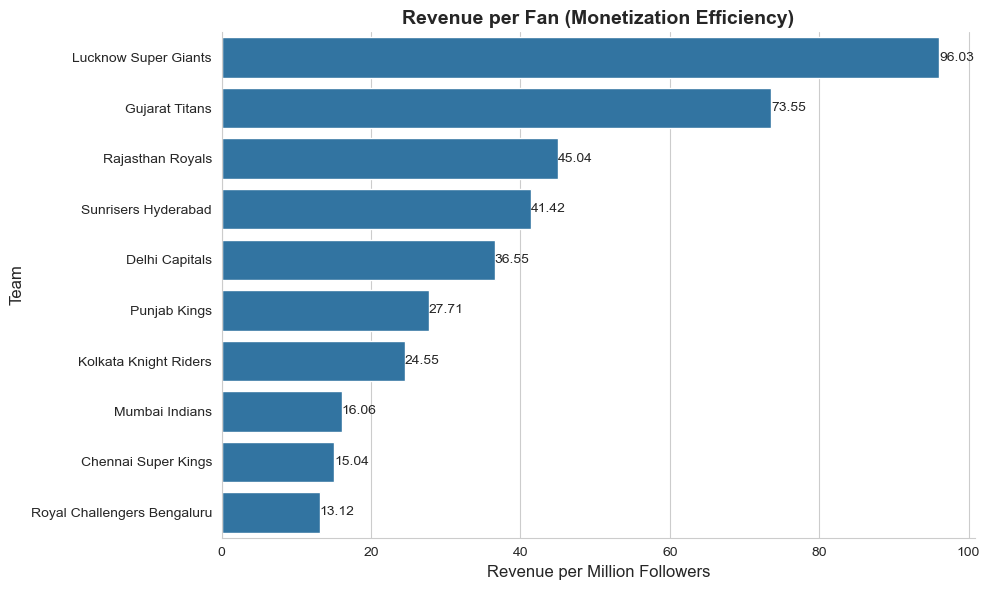

In [ ]:


# Sort data
df_sorted = df.sort_values('revenue_per_fan', ascending=False)

# Create figure
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

# Plot bar chart
ax = sns.barplot(
    data=df_sorted,
    x='revenue_per_fan',
    y='team'
)

# Add value labels on bars





# Titles and labels
plt.title("Revenue per Fan (Monetization Efficiency)", fontsize=14, fontweight='bold')
plt.xlabel("Revenue per Million Followers", fontsize=12)
plt.ylabel("Team", fontsize=12)

# Clean look
sns.despine()
plt.tight_layout()

# Show plot
plt.show()

In [18]:
df

,rank,team,followers_m,brand_value_usd_m,net_worth_cr,FY25 Revenue (Rs Cr),total_matches_played,total_wins,win_percentage,is_top_team,business_score,revenue_per_fan
0,1,Chennai Super Kings,44.8,235.0,2033.0,674,255,142,55.7,True,171.60,15.044643
1,2,Mumbai Indians,41.4,242.0,2094.0,665,279,152,54.5,True,175.30,16.062802
2,3,Royal Challengers Bengaluru,38.4,269.0,2327.0,504,272,133,48.9,True,192.56,13.125000
3,4,Kolkata Knight Riders,30.8,222.0,1918.0,756,267,135,50.6,False,158.60,24.545455
4,5,Punjab Kings,17.0,141.0,1219.0,471,265,121,45.7,False,99.98,27.705882
5,6,Delhi Capitals,16.5,152.0,1314.0,603,268,120,44.8,False,107.23,36.545455
6,7,Sunrisers Hyderabad,15.5,154.0,1331.0,642,198,94,47.5,False,108.27,41.419355
7,8,Rajasthan Royals,14.1,146.0,1262.0,635,238,115,48.3,False,102.47,45.035461
8,9,Gujarat Titans,7.6,142.0,1227.0,559,62,37,59.7,False,97.82,73.552632
9,10,Lucknow Super Giants,5.8,122.0,1054.0,557,59,30,50.8,False,83.82,96.034483


/var/folders/23/m7plmfj94kb8p9ghd1v3b9lh0000gn/T/ipykernel_57124/1836221230.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.barplot(


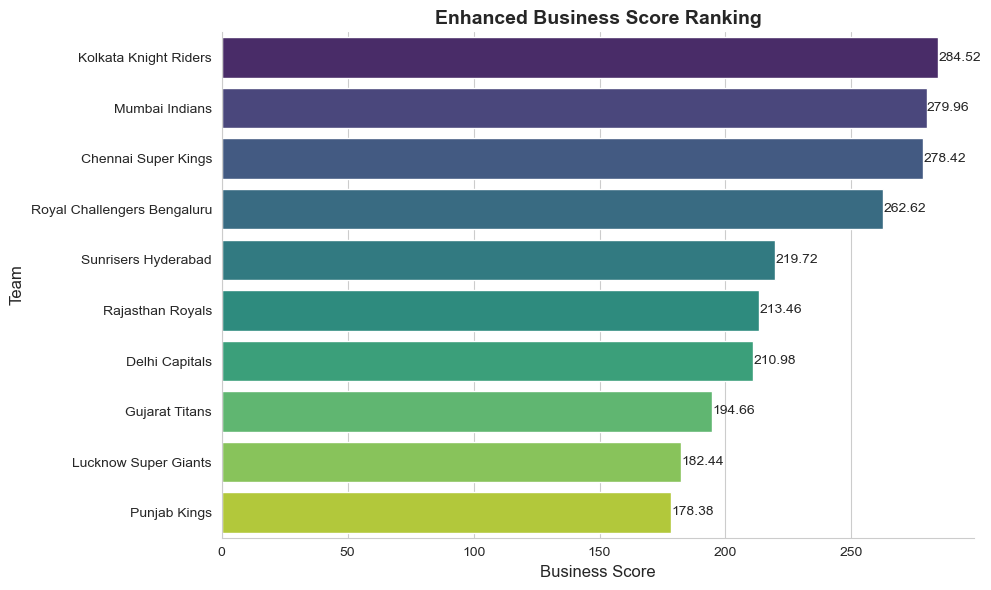

In [19]:
df['business_score_v2'] = (
    0.4 * df['brand_value_usd_m'] +
    0.2 * df['followers_m'] +
    0.2 * df['net_worth_cr'] / 10 +
    0.2 * df['FY25 Revenue (Rs Cr)']
)

df_sorted = df.sort_values('business_score_v2', ascending=False)

plt.figure(figsize=(10,6))

ax= sns.barplot(
    data=df_sorted,
    x='business_score_v2',
    y='team',
    palette='viridis'
)
# Add value labels on bars
for i, v in enumerate(df_sorted['business_score_v2']):
    ax.text(
        v + 0.01,          # position (slightly right of bar)
        i,                 # y position
        f"{v:.2f}",        # format value
        va='center',       # vertical alignment
        fontsize=10
    )

plt.title("Enhanced Business Score Ranking", fontsize=14, fontweight='bold')
plt.xlabel("Business Score", fontsize=12)
plt.ylabel("Team", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

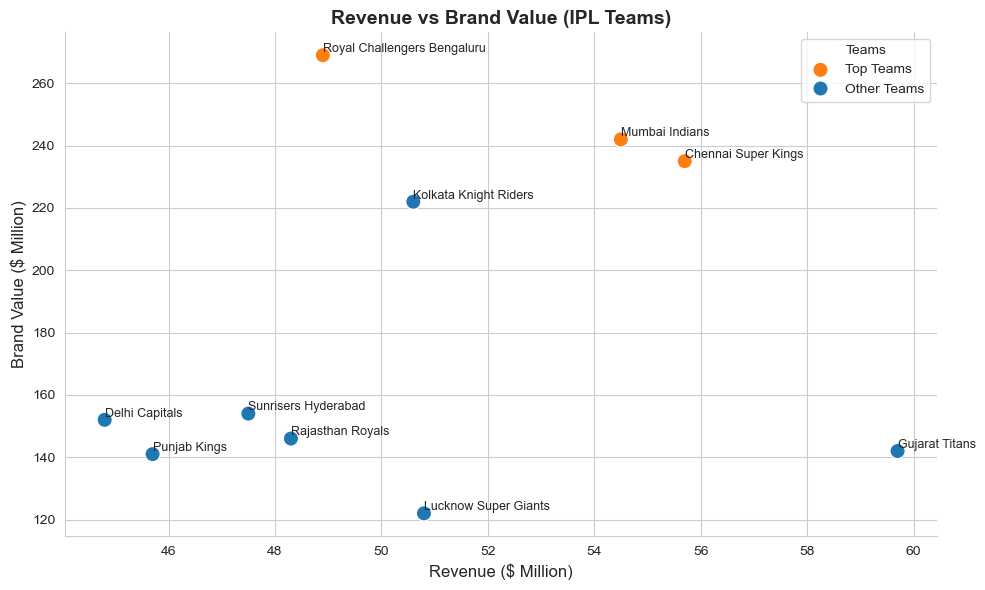

In [20]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

# Create a column to highlight top teams
top_teams = ['Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bengaluru']
df['is_top_team'] = df['team'].isin(top_teams)

sns.scatterplot(
    data=df,
    x='win_percentage',
    y='brand_value_usd_m',
    hue= df['is_top_team'],
    s=120
)

# Add team labels
for i in range(len(df)):
    plt.text(
        df['win_percentage'][i] ,
        df['brand_value_usd_m'][i] + 1,
        df['team'][i],
        fontsize=9
    )

# Titles and labels
plt.title("Revenue vs Brand Value (IPL Teams)", fontsize=14, fontweight='bold')
plt.xlabel("Revenue ($ Million)", fontsize=12)
plt.ylabel("Brand Value ($ Million)", fontsize=12)
plt.legend(title= 'Teams', labels=['Top Teams', 'Other Teams'], loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

In [21]:
df

,rank,team,followers_m,brand_value_usd_m,net_worth_cr,FY25 Revenue (Rs Cr),total_matches_played,total_wins,win_percentage,is_top_team,business_score,revenue_per_fan,business_score_v2
0,1,Chennai Super Kings,44.8,235.0,2033.0,674,255,142,55.7,True,171.60,15.044643,278.42
1,2,Mumbai Indians,41.4,242.0,2094.0,665,279,152,54.5,True,175.30,16.062802,279.96
2,3,Royal Challengers Bengaluru,38.4,269.0,2327.0,504,272,133,48.9,True,192.56,13.125000,262.62
3,4,Kolkata Knight Riders,30.8,222.0,1918.0,756,267,135,50.6,False,158.60,24.545455,284.52
4,5,Punjab Kings,17.0,141.0,1219.0,471,265,121,45.7,False,99.98,27.705882,178.38
5,6,Delhi Capitals,16.5,152.0,1314.0,603,268,120,44.8,False,107.23,36.545455,210.98
6,7,Sunrisers Hyderabad,15.5,154.0,1331.0,642,198,94,47.5,False,108.27,41.419355,219.72
7,8,Rajasthan Royals,14.1,146.0,1262.0,635,238,115,48.3,False,102.47,45.035461,213.46
8,9,Gujarat Titans,7.6,142.0,1227.0,559,62,37,59.7,False,97.82,73.552632,194.66
9,10,Lucknow Super Giants,5.8,122.0,1054.0,557,59,30,50.8,False,83.82,96.034483,182.44


In [22]:
df_plot= df[['FY25 Revenue (Rs Cr)','win_percentage']]

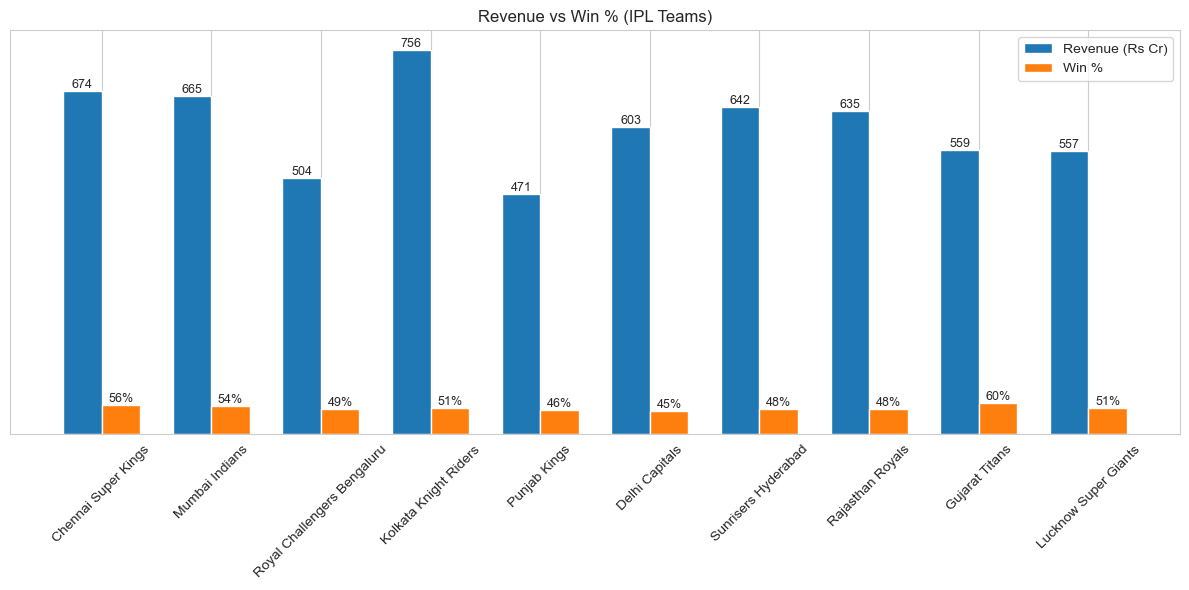

In [23]:


teams = df['team']
revenue = df['FY25 Revenue (Rs Cr)']
win_pct = df['win_percentage']

x = np.arange(len(teams))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

bars1 = ax.bar(x - width/2, revenue, width, label='Revenue (Rs Cr)')
bars2 = ax.bar(x + width/2, win_pct, width, label='Win %')

# Remove Y-axis
ax.set_yticks([])
ax.set_ylabel('')

# X labels
ax.set_xticks(x)
ax.set_xticklabels(teams, rotation=45)

# Title & legend
ax.set_title('Revenue vs Win % (IPL Teams)')
ax.legend()

# Add value labels on bars
def add_labels(bars, is_percentage=False):
    for bar in bars:
        height = bar.get_height()
        label = f'{height:.0f}%' if is_percentage else f'{height:.0f}'
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            label,
            ha='center',
            va='bottom',
            fontsize=9
        )

add_labels(bars1)              # Revenue labels
add_labels(bars2, True)       # Win % labels

plt.tight_layout()
plt.show()

In [32]:
df_wins= df.sort_values(by='win_percentage', ascending=False)[['team', 'win_percentage']]

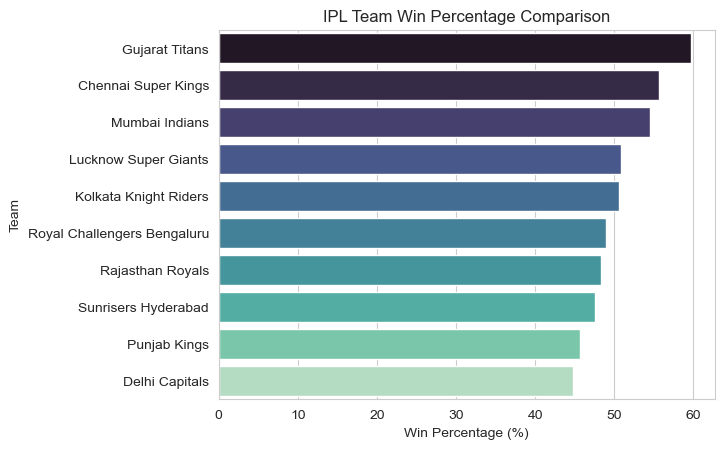

In [36]:
sns.barplot(data=df_wins, x='win_percentage', y='team', hue='team', palette='mako')
plt.title("IPL Team Win Percentage Comparison")
plt.xlabel("Win Percentage (%)")
plt.ylabel("Team")
for i, v in enumerate(df_wins['win_percentage']):
    ax.text(
        v + 0.01,          # position (slightly right of bar)
        i,                 # y position
        f"{v:.2f}",        # format value
        va='center',       # vertical alignment
        fontsize=10
    )
plt.show()